<a href="https://colab.research.google.com/github/slogan02/Final_Project/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Startup**

In [ ]:
# Mount file into my drive
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [ ]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Student_Performance_Data.csv')
df

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1


# **Data Exploration**

In [ ]:
# Basic Statistics for Each Variable
print(df.shape)
print(df.info())
print(df.describe())

(2392, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   int64  
dtypes: float64(2), int64(13)
memory usage: 280.4 KB
None
        

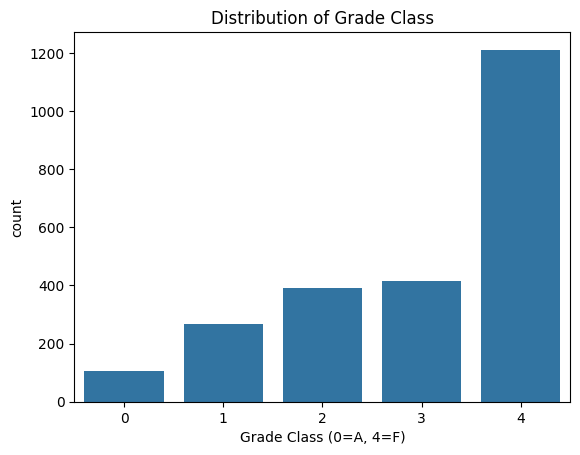

In [ ]:
# Target Variable Distribution Plot
sns.countplot(x='GradeClass', data=df)
plt.title("Distribution of Grade Class")
plt.xlabel("Grade Class (0=A, 4=F)")
plt.show()

In [ ]:
# Check for any Missing Values
missing_values = df.isnull().sum()

print("Missing Values by Variable:")
print(missing_values)

Missing Values by Variable:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


### **Data Visualizations**

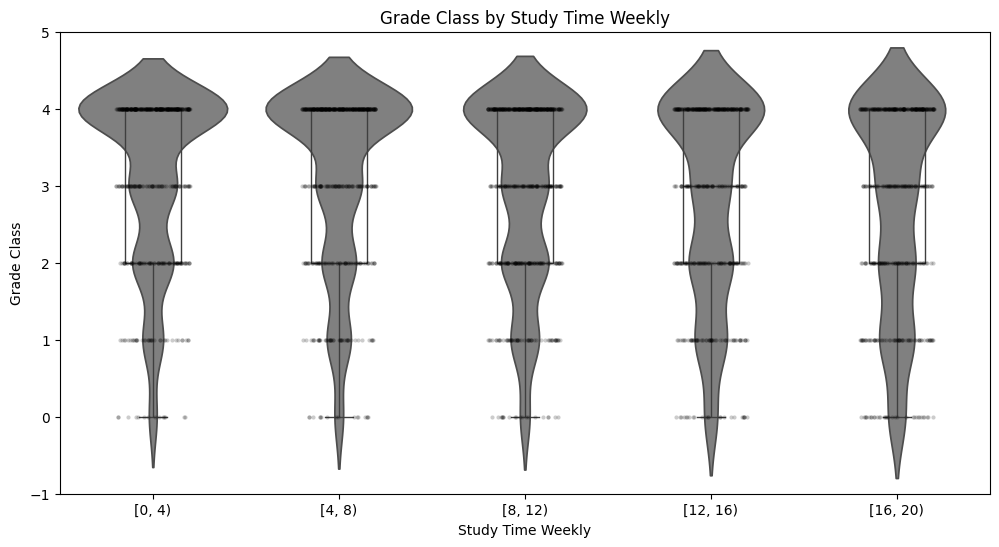

In [ ]:
## Grade Class by Study Time Weekly
# Create figure and define bins for visualization
plt.figure(figsize=(12,6))
bin_edges = list(range(0, 21, 4))

# Convert data into categorical bins and into string format
df['StudyTimeBin'] = pd.cut(df['StudyTimeWeekly'], bins=bin_edges, include_lowest=True, right=False)
df['StudyTimeBinStr'] = df['StudyTimeBin'].astype(str)
# Order bins
df['StudyTimeBinStr'] = pd.Categorical(df['StudyTimeBinStr'], categories=[str(interval) for interval in df['StudyTimeBin'].cat.categories], ordered=True)
# Violin Plot
sns.violinplot(x='StudyTimeBinStr', y='GradeClass', data=df, inner=None, color='gray')
# Boxplot Overlay
sns.boxplot(x='StudyTimeBinStr', y='GradeClass', data=df, showcaps=True, boxprops={'facecolor':'None'}, width=0.3)
# Strip Plot
sns.stripplot(x='StudyTimeBinStr', y='GradeClass', data=df, color='black', alpha=0.2, jitter=0.2, size=3)

# Labeling
plt.xlabel('Study Time Weekly')
plt.ylabel('Grade Class')
plt.title('Grade Class by Study Time Weekly')
plt.ylim(-1, 5)
plt.show()

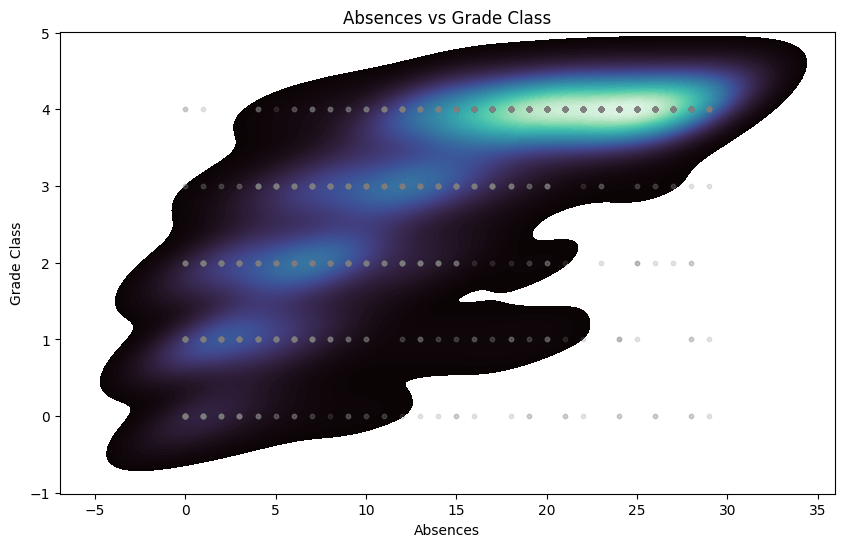

In [ ]:
## Grade Class by Absences
# Create figure
plt.figure(figsize=(10,6))
#KDE Plot
sns.kdeplot( x=df['Absences'], y=df['GradeClass'], fill=True, thresh=0.03, levels=100, cmap="mako")

# Scatter Plot
plt.scatter(df['Absences'], df['GradeClass'], s=10, alpha=0.2, color='gray')

# Labeling
plt.xlabel('Absences')
plt.ylabel('Grade Class')
plt.title('Absences vs Grade Class')
plt.show()

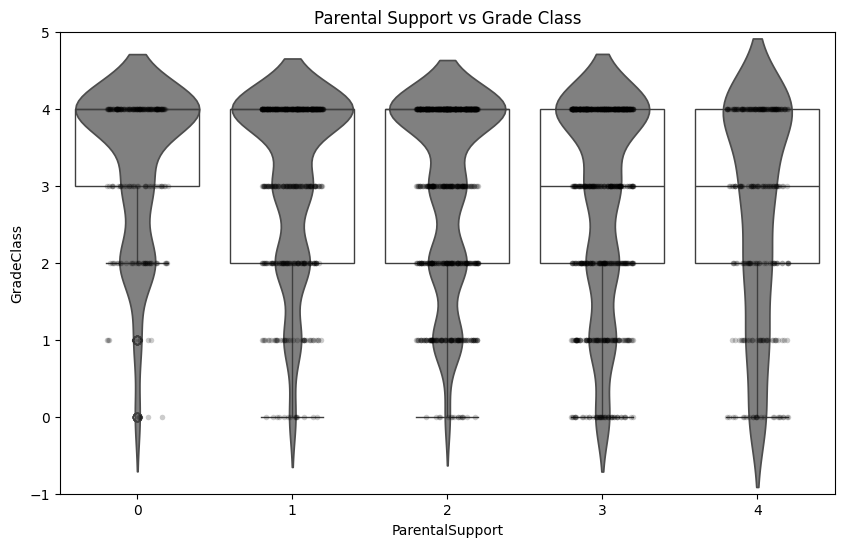

In [ ]:
## Grade Class vs Parental Support (0-Low, 4-High)
# Create figure
plt.figure(figsize=(10,6))

# Violin Plot
sns.violinplot(x='ParentalSupport', y='GradeClass', data=df, inner=None, color="gray")
# Boxplot Overlay
sns.boxplot(x='ParentalSupport', y='GradeClass', data=df, boxprops={'facecolor':'None'})
# Strip Plot
sns.stripplot(x='ParentalSupport', y='GradeClass', data=df, jitter=0.2, size=4, alpha=0.2, color='black')

# Labeling
plt.ylim(-1,5)
plt.title('Parental Support vs Grade Class')
plt.show()


The dataset contains no missing values (Thank God), meaning no removal process is needed during the preprocessesing stage. The target variable, GradeClass, has a slight imbalance. Some grade categories appear more frequently than others. Additionally, key relationships with the study time variable, absences, and parental support can be observed with the target variable. This analysis can indicate these variables may be important predictors in the model.



**Feature Engineering**

In [ ]:
# Study efficiency
df['StudyEfficiency'] = df['StudyTimeWeekly'] / (df['Absences'] + 1)

# Combined support
df['TotalSupport'] = df['ParentalSupport'] + df['Tutoring']

# Activity engagement
df['ActivityScore'] = df['Sports'] + df['Music'] + df['Volunteering']

1. **Study Effiency**
The formula is 'StudyEfficiency' = 'StudyTimeWeekly' / ('Absences' + 1)
This feature captures how effectively a student uses their study time relative to attendance. While study time and abscenses individually provide useful information, combining reveals the efficiency rating and whether a student is managing time well.
Both attendance and study time are important to success. A student who studies frequently and attends class will perform well, vice versa.

2. **Combined Support**
The formula is 'TotalSupport' = 'ParentalSupport' + 'Tutoring'
This feature combines two forms of academic support into a single variable. This captures the level of assistance a student receives. It provides a more complete picture.
Students who receive support both at home and tutoring are more likely to perform better academically. Combining these factors reflects the cumulative effect of academic support systems.

3. **Activity Score**
The formula is 'ActivityScore' = 'Sports' + 'Music' + 'Volunteering'
This feature measures overall student engagement in extracurricular activities, which may influence time management, discipline, and overall performance.
Participation in extracurricular activities is often associated with improved social skills, time management, and personal development, all of which can positively impact academic performance when balanced appropriately.

**Data Prepartion**

In [ ]:
# Remove insignificant variables and target
X = df.drop(['GradeClass', 'StudentID', 'GPA'], axis=1)
# Target Variable
y = df['GradeClass']

In [ ]:
# Categorical Columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Initialize Scaler
scaler = StandardScaler()
# Fit scaler on data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## **Random Forest**

In [ ]:
## Random Forest
# Initialize Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train Model
rf.fit(X_train, y_train)
# Generate Predictions
rf_preds = rf.predict(X_test)
# Print Model Performance
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.7160751565762005
              precision    recall  f1-score   support

           0       0.38      0.14      0.21        21
           1       0.56      0.56      0.56        54
           2       0.53      0.59      0.56        78
           3       0.49      0.53      0.51        83
           4       0.91      0.91      0.91       243

    accuracy                           0.72       479
   macro avg       0.57      0.54      0.55       479
weighted avg       0.71      0.72      0.71       479



### **Random Forest Confusion Matrix**

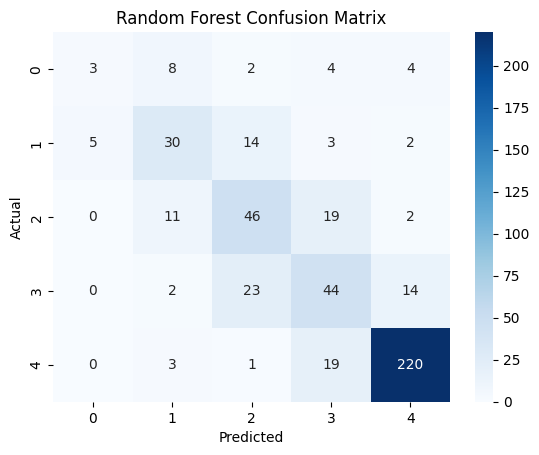

In [ ]:
# Create Confusion Matrix
cm = confusion_matrix(y_test, rf_preds)
# Plot Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# Labeling
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Random Forest Confusion Matrix")
plt.show()

## **Neural Network**

In [ ]:
## Neural Network
# Initialize Classifier
nn = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

# Train Model
nn.fit(X_train, y_train)
# Generate Predictions
nn_preds = nn.predict(X_test)
# Print Model Performance
print("Neural Network Accuracy:", accuracy_score(y_test, nn_preds))
print(classification_report(y_test, nn_preds))

Neural Network Accuracy: 0.6617954070981211
              precision    recall  f1-score   support

           0       0.23      0.24      0.23        21
           1       0.44      0.39      0.41        54
           2       0.51      0.59      0.55        78
           3       0.45      0.52      0.48        83
           4       0.90      0.83      0.87       243

    accuracy                           0.66       479
   macro avg       0.51      0.51      0.51       479
weighted avg       0.68      0.66      0.67       479



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


### **Neural Network Confusion Matrix**

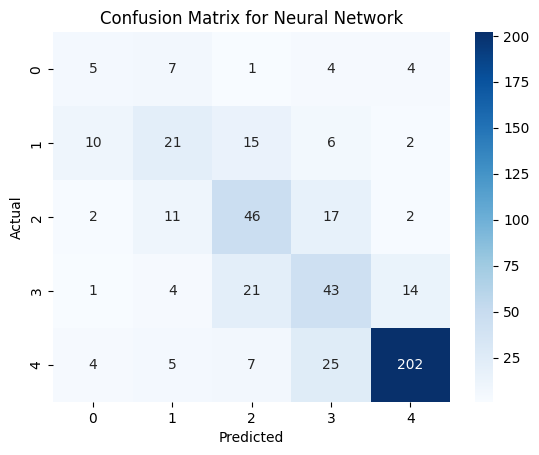

In [ ]:
# Create Confusion Matrix
cm = confusion_matrix(y_test, nn_preds)
# Generate Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=True, yticklabels=True)
# Labeling
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Neural Network')
plt.show()

## **Compare Model Performance**

In [ ]:
# Import scoring metrics and time
from sklearn.metrics import precision_score, recall_score, f1_score, mean_squared_error, mean_absolute_error
import time

# Record training time for Random Forest
start_rf = time.time()
rf.fit(X_train, y_train)
end_rf = time.time()
rf_time = end_rf - start_rf

# Record training time for Neural Network
start_nn = time.time()
nn.fit(X_train, y_train)
end_nn = time.time()
nn_time = end_nn - start_nn

# Create Dataframe to Compare Model Performance
results = pd.DataFrame({
    "Model": ["Random Forest", "Neural Network"],
    # Accuracy
    "Accuracy": [accuracy_score(y_test, rf_preds), accuracy_score(y_test, nn_preds)],
    # Precision
    "Precision": [precision_score(y_test, rf_preds, average='weighted'), precision_score(y_test, nn_preds, average='weighted')],
    # Recall
    "Recall": [recall_score(y_test, rf_preds, average='weighted'), recall_score(y_test, nn_preds, average='weighted')],
    # F1
    "F1 Score": [f1_score(y_test, rf_preds, average='weighted'), f1_score(y_test, nn_preds, average='weighted')],
    # RMSE
    "RMSE": [np.sqrt(mean_squared_error(y_test, rf_preds)), np.sqrt(mean_squared_error(y_test, nn_preds))],
    # MAE
    "MAE": [mean_absolute_error(y_test, rf_preds), mean_absolute_error(y_test, nn_preds)],
    # Training Time
    "Training Time": [rf_time, nn_time]
})

# Print Results
results


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1 Score,RMSE,MAE,Training Time (s)
0,Random Forest,0.716075,0.713024,0.716075,0.711941,0.788752,0.367432,0.671110
1,Neural Network,0.661795,0.678427,0.661795,0.668378,0.962773,0.484342,6.076062


The Random Forest model performs better overall, achieving higher accuracy and more consistent precision, recall, and F1 scores. This is likely because Random Forest is better suited for structured data and can effectively capture relationships between features without extensive tuning. In contrast, the Neural Network model offers greater flexibility in modeling complex patterns. Unfortunately, it requires more computational time and is less interpretable, making it harder to explain results. Given all this, the Random Forest model is the preferred choice for the final submission due to its stronger performance and faster training time.

# **Reflection**



Based on my initial results, additional feature engineering variables will focus on capturing more complex relationships between student behavior and performance. They will likely combine study time and parental support to better reflect how suppot systems influence study habits. Additionally, to create categories for absences to better capture nonlinear effects. Expanding beyond the initial three engineered features will help uncover deeper patterns that may improve model performance.

To improve the performance of the selected model, I plan to apply advanced tuning techniques. This will include optimizing parameters like the number of trees, maximum depth, and minimum samples per split to reduce overfitting and improve generalization. Also, I will explore feature selection methods to remove less important variables and improve efficiency. For the neural network, a potential improvement is adjusting the network architecture and adding regularization to address possible overfitting observed in the initial results.

One area where I would like help is on the significance of my engineered features and whether they meaningfully capture the relationships within the data. Additionally, guidance on whether additional preprocessing steps, such as further feature scaling or dimensionality reduction would significantly improve model performance would be valuable.